9.8 26.2 47.800000000000004 49.4 81.9 106.60000000000001 109.80000000000001
(100,) (100,)


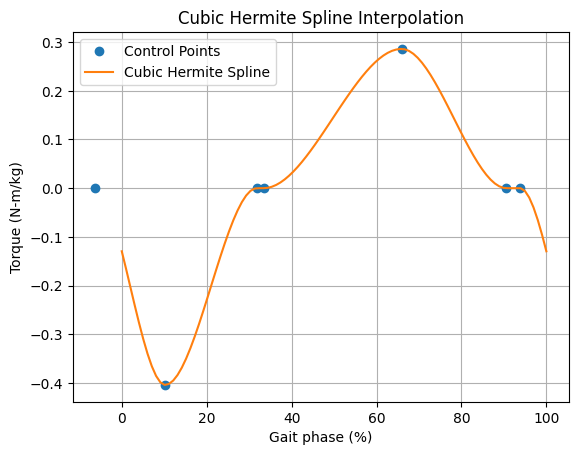

In [6]:
import numpy as np
from scipy.interpolate import CubicHermiteSpline
import pandas as pd

class Spline:
    def __init__(self, ):
        peak_time = 26.2
        rise_time = 16.4
        mid_time = 48.6
        mid_dur = 1.6
        peak_time_2 = 81.9
        fall_time = 24.7
        gp_offset = 16

        peak_extension_torque = -0.404
        peak_flexion_torque = 0.286

        print(peak_time-rise_time, peak_time, mid_time - mid_dur/2, mid_time + mid_dur/2, peak_time_2, peak_time_2+fall_time, 100+peak_time-rise_time)

        self.spline_x = np.array([peak_time-rise_time-gp_offset, peak_time-gp_offset, mid_time-mid_dur/2-gp_offset, mid_time+mid_dur/2-gp_offset, peak_time_2-gp_offset, peak_time_2+fall_time-gp_offset, 100+peak_time-rise_time-gp_offset])
        self.spline_y = np.array([0.0, peak_extension_torque, 0.0, 0.0, peak_flexion_torque, 0.0, 0.0])
        self.spline_dydx = np.array([0, 0.0, 0.0, 0, 0.0, 0.0, 0])
        self.spline_profile = CubicHermiteSpline(self.spline_x,
                                               self.spline_y,
                                               self.spline_dydx, extrapolate='periodic')

    def plot_spline(self):
        import matplotlib.pyplot as plt

        self.x = np.linspace(0, 100, 100)
        self.y = self.spline_profile(self.x)
        print(self.x.shape, self.y.shape)

        plt.plot(self.spline_x, self.spline_y, 'o', label='Control Points')
        plt.plot(self.x, self.y, label='Cubic Hermite Spline')
        plt.title('Cubic Hermite Spline Interpolation')
        plt.xlabel('Gait phase (%)')
        plt.ylabel('Torque (N-m/kg)')
        plt.legend()
        plt.grid()
        plt.show()

    def save_spline(self):
        df = pd.DataFrame(self.y)
        df.to_csv('spline_profile.csv', index=False, header=False)

spline = Spline()
spline.plot_spline()
spline.save_spline()

print()

In [8]:
spline_profile = np.loadtxt('spline_profile.csv')
print(spline_profile.shape)

(100,)
